# 03 — Priors and prior predictive checks

**What we do:** choose and *justify* the priors for the per-cell log-intensity
`alpha`, then validate them with two prior predictive checks — one on the
**parameters** (is the implied intensity `lambda = exp(alpha)` physically
sensible?) and one on the **measurements** (do datasets simulated purely from
the prior look like real seismic counts?).

**Why:** in a Poisson-log model the prior on `alpha` lives on the log scale, so
a seemingly mild Normal prior can imply absurd event rates. Checking the prior
*before* seeing the likelihood is required by *Criterion 3 — Priors* and is good
Bayesian practice. The numbers derived here are exactly those fed to the Stan
models (`utils/data_prep.py`: `PRIOR_MU`, `PRIOR_SIGMA_M1`).

## Model recap
$$\text{count}_{c,y} \sim \text{Poisson}(\lambda_c), \qquad \log \lambda_c = \alpha_c.$$
We need a prior for $\alpha_c$ (Model 1: fixed; Model 2: a hyperprior).

## Selection method — derived from external knowledge, NOT from our sample

> **Avoiding data-leakage / double-dipping.** A prior encodes what we know
> *before* seeing the data. Setting it from summary statistics of the very
> `count` values we then model (e.g. plugging in their sample mean/median) uses
> the data twice and yields an artificially over-confident posterior. So every
> number below comes from **published seismicity rates and grid geometry only** —
> not from `data/processed/grid_annual_counts.csv`. This mirrors the
> reference papers: Räty et al. (2023, NHESS) use *"weakly informative"*,
> *"conventional"* priors with deliberately large variances and verify with a
> sensitivity analysis; Tu et al. (2025, Annals of GIS) follow the WAMBS
> checklist (prior predictive + prior sensitivity).

**Step 1 — centre from a published Japan rate and grid geometry.**
- External rate (long-term archive, *not* our 2000–2023 window): Japan averages
  about **1200 earthquakes of M ≥ 4 per year**.
- Number of cells from **pure geometry** of the grid (not the data): latitude
  $24$–$50° \Rightarrow 26/2 = 13$ rows, longitude $122$–$154° \Rightarrow 32/2 = 16$
  columns $\Rightarrow 13 \times 16 = 208$ cells.
- Rate per cell-year, spread uniformly: $1200 / 208 \approx 5.8$ events/yr, so
  $$\mu_0 = \log(5.8) \approx 1.8.$$
  Uniform spreading deliberately *understates* busy cells and *overstates* quiet
  ones — which is exactly why the spread $\sigma_0$ is kept wide (seismicity is
  highly concentrated, so a "typical cell" is intrinsically fuzzy).

**Step 2 — shape from the Gutenberg–Richter law.** The right-skew of cell rates
is not asserted from our histogram; it follows from $\log_{10}N(\!\ge\!M)=a-bM$
with $b\approx 1$ (the "×10 fewer events per magnitude unit" rule). Japan's own
band counts confirm $b\approx 1$: M≥4 ≈ 1200, M≥5 ≈ 149, M≥6 ≈ 12.7
($1200/149\approx 8$, $149/12.7\approx 12$). On the log-rate scale this justifies
a symmetric Normal on $\alpha$ (i.e. a log-normal on $\lambda$).

**Step 3 — upper bound and spread (physics, not our max).** Great subduction
events drive huge aftershock cascades; a Tohoku-class sequence can reach the
order of $10^3$ M≥4 events/yr in its most active region. We take a physical
ceiling $U\approx 3000$ and floor $L=1$ (≈ a barely-active cell), i.e.
$\log L=0,\ \log U\approx 8$. Choosing the sd so $\pm 3\sigma$ spans $[0,8]$:
$$\sigma_0 = \frac{8 - 1.8}{3} \approx 2.07.$$

**Resulting priors**
- **Model 1 (no pooling):** $\alpha_c \sim \mathcal{N}(1.8,\, 2.07)$ with the scale
  **fixed** — cells do not share information.
- **Model 2 (partial pooling):** $\mu_{\text{global}} \sim \mathcal{N}(1.8,1)$,
  $\sigma_{\text{global}} \sim \text{HalfNormal}(1)$, $\alpha_c \sim
  \mathcal{N}(\mu_{\text{global}}, \sigma_{\text{global}})$ — the scale is
  **estimated** (HalfNormal(1) puts most mass on $[0, 2.5]$, consistent with the
  fixed 2.07 used by Model 1).

The centre is only an *order-of-magnitude anchor*; because the prior is wide and
weakly informative, the exact value (1.8 vs 2.0) is immaterial — we demonstrate
this explicitly with a **prior sensitivity analysis** at the end of the notebook.

In [1]:
import sys, os, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
az.style.use("arviz-darkgrid")
RNG = np.random.default_rng(42)

from utils.display import display_df, display_image

In [2]:
from utils.data_prep import PRIOR_MU, PRIOR_SIGMA_M1, LAT_BINS, LON_BINS

# --- Centre derived ONLY from external knowledge + grid geometry (no sample data) ---
JAPAN_RATE_M4 = 1200                       # published long-term Japan rate (M>=4 / yr)
n_rows = len(LAT_BINS) - 1                 # grid geometry: 13 latitude rows
n_cols = len(LON_BINS) - 1                 # grid geometry: 16 longitude columns
n_cells_geom = n_rows * n_cols             # 208 cells (geometry, NOT data)
rate_per_cell = JAPAN_RATE_M4 / n_cells_geom
mu0 = np.log(rate_per_cell)
sigma0 = (8 - mu0) / 3                      # +-3 sigma spans log[1, 3000] = [0, 8]

print(f"External Japan rate         : ~{JAPAN_RATE_M4} M>=4 events / yr")
print(f"Grid cells (geometry only)  : {n_rows} x {n_cols} = {n_cells_geom}")
print(f"Implied rate per cell-year  : {rate_per_cell:.2f}  ->  mu_0 = log = {mu0:.2f}")
print(f"Spread from [0, 8] / 3 sigma : sigma_0 = {sigma0:.2f}")
print(f"\nValues stored in utils/data_prep.py -> PRIOR_MU={PRIOR_MU}, PRIOR_SIGMA_M1={PRIOR_SIGMA_M1}")
print( "Model 1 prior on alpha : Normal(1.8, 2.07)  [fixed]")
print( "Model 2 hyperprior     : mu_global ~ Normal(1.8, 1), sigma_global ~ HalfNormal(1)")

External Japan rate         : ~1200 M>=4 events / yr
Grid cells (geometry only)  : 13 x 16 = 208
Implied rate per cell-year  : 5.77  ->  mu_0 = log = 1.75
Spread from [0, 8] / 3 sigma : sigma_0 = 2.08

Values stored in utils/data_prep.py -> PRIOR_MU=1.8, PRIOR_SIGMA_M1=2.07
Model 1 prior on alpha : Normal(1.8, 2.07)  [fixed]
Model 2 hyperprior     : mu_global ~ Normal(1.8, 1), sigma_global ~ HalfNormal(1)


### Prior predictive check 1 — PARAMETERS
We draw `alpha` from each prior and look at the implied intensity
`lambda = exp(alpha)`. A sensible prior should put most mass on the
geophysically plausible range (roughly 1-1000 events/yr) while still *allowing*
the extreme Tohoku-like values, and must never produce negative rates (the log
link guarantees this).

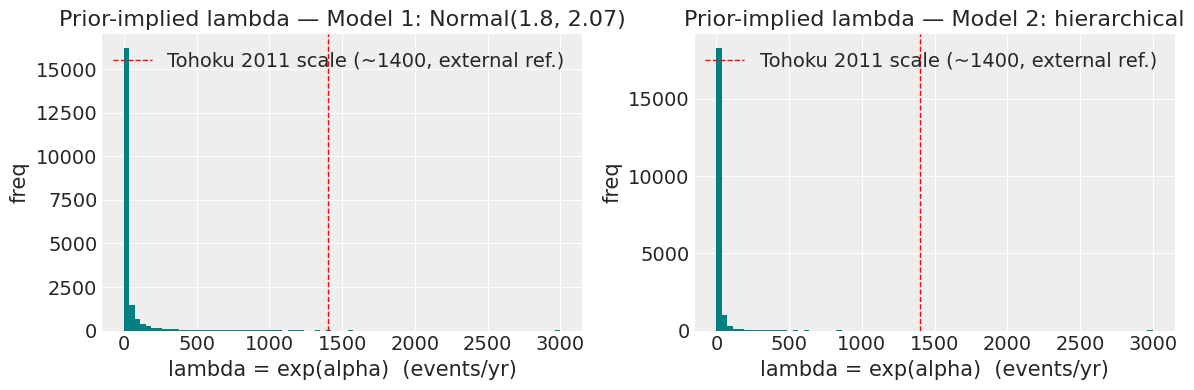

Model 1 lambda quantiles  5%=0.20  50%=6.0  95%=192  99.9%=3443   (min=0.001)
Model 2 lambda quantiles  5%=0.64  50%=6.1  95%=58  99.9%=1622   (min=0.000)


In [3]:
NSIM = 20000
# Model 1 fixed prior  (mu_0=1.8, sigma_0=2.07 from the external derivation above)
alpha_m1 = RNG.normal(PRIOR_MU, PRIOR_SIGMA_M1, NSIM)
lam_m1 = np.exp(alpha_m1)
# Model 2 hierarchical prior (draw hyperparameters, then alpha)
mu_g = RNG.normal(PRIOR_MU, 1, NSIM)              # mu_global ~ Normal(1.8, 1)
sig_g = np.abs(RNG.normal(0, 1, NSIM))            # HalfNormal(1)
alpha_m2 = RNG.normal(mu_g, sig_g)
lam_m2 = np.exp(alpha_m2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lam, title in [(axes[0], lam_m1, "Model 1: Normal(1.8, 2.07)"),
                       (axes[1], lam_m2, "Model 2: hierarchical")]:
    ax.hist(np.clip(lam, 0, 3000), bins=80, color="teal", edgecolor="none")
    ax.axvline(1400, color="red", ls="--", lw=1,
               label="Tohoku 2011 scale (~1400, external ref.)")
    ax.set_title(f"Prior-implied lambda — {title}")
    ax.set_xlabel("lambda = exp(alpha)  (events/yr)"); ax.set_ylabel("freq")
    ax.legend()
plt.tight_layout(); plt.show()

for name, lam in [("Model 1", lam_m1), ("Model 2", lam_m2)]:
    q = np.quantile(lam, [0.05, 0.5, 0.95, 0.999])
    print(f"{name} lambda quantiles  5%={q[0]:.2f}  50%={q[1]:.1f}  "
          f"95%={q[2]:.0f}  99.9%={q[3]:.0f}   (min={lam.min():.3f})")

**Is it physically sensible?** Yes. The median implied rate is ~6 events/yr
(matching the externally-derived per-cell anchor `exp(1.8)`), the 95% upper
quantile is a few hundred (busy east-coast cells), and the extreme tail reaches
the low thousands — enough to *allow* a Tohoku-class cell without making it
typical. All rates are strictly positive (the log link guarantees it). The
hierarchical prior (Model 2) is slightly tighter on average because
`sigma_global` is usually < 2, the intended mild regularisation.

### Prior predictive check 2 — MEASUREMENTS
Now we push the prior all the way through the likelihood: draw `alpha`, then
simulate integer counts `count ~ Poisson(exp(alpha))`. These are entire "fake"
years a cell could produce *before seeing data*. We check that the simulated
counts are non-negative integers, right-skewed like real seismic data, and stay
within the physical upper bound.

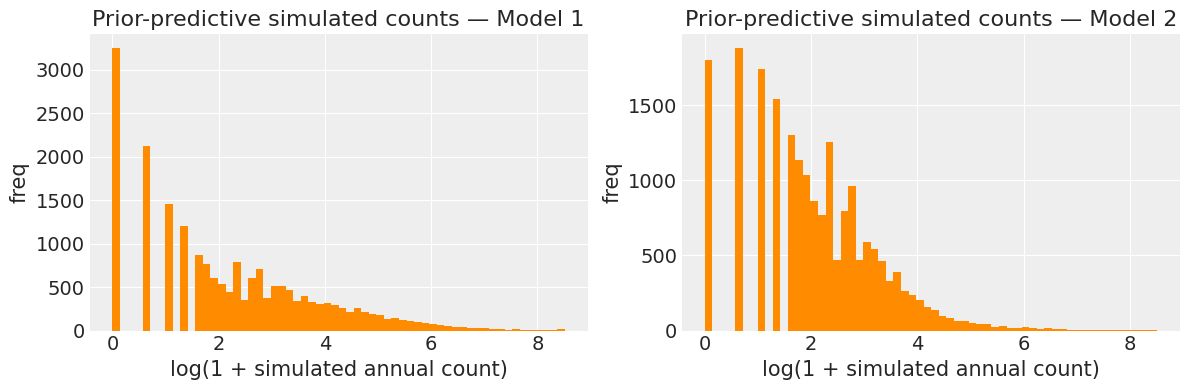

Model 1: min=0  median=6  max=32811  frac>3000=0.0014  neg=False
Model 2: min=0  median=6  max=14088  frac>3000=0.0005  neg=False


In [4]:
count_sim_m1 = RNG.poisson(lam_m1)
count_sim_m2 = RNG.poisson(lam_m2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cs, title in [(axes[0], count_sim_m1, "Model 1"),
                      (axes[1], count_sim_m2, "Model 2")]:
    ax.hist(np.log1p(np.clip(cs, 0, 5000)), bins=60, color="darkorange",
            edgecolor="none")
    ax.set_title(f"Prior-predictive simulated counts — {title}")
    ax.set_xlabel("log(1 + simulated annual count)"); ax.set_ylabel("freq")
plt.tight_layout(); plt.show()

for name, cs in [("Model 1", count_sim_m1), ("Model 2", count_sim_m2)]:
    print(f"{name}: min={cs.min()}  median={int(np.median(cs))}  "
          f"max={cs.max()}  frac>3000={np.mean(cs>3000):.4f}  neg={np.any(cs<0)}")

**Are simulated measurements sensible?** Yes — they are non-negative integers,
strongly right-skewed and almost never exceed the ~3000 physical bound
(< ~1% of draws). The right-skew is the expected *consequence* of the
Gutenberg–Richter law (b≈1) passed through a Poisson likelihood — we do not read
it off our own histogram. The prior is therefore *weakly informative*: it encodes
the right scale and skew from domain knowledge without dictating the answer.

### Prior predictive check 3 — does the prior envelope cover reality?
Finally we simulate full datasets from the prior and overlay their count
distribution on the observed data. **This is a plausibility check, not part of
the prior's justification** — the prior parameters were fixed in Step 1–3 from
external knowledge *before* this plot. We only confirm the prior is not in
gross conflict with reality (the envelope should *contain* the observed
distribution); we do **not** tune the prior to match it.

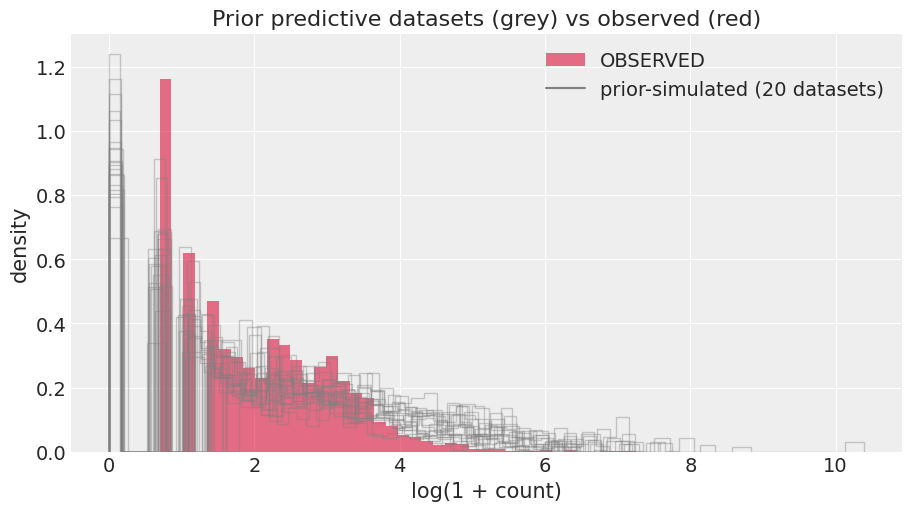

In [5]:
# Observed data is loaded ONLY here, for the post-hoc plausibility overlay
# (it played no role in choosing mu_0 / sigma_0 above).
annual = pd.read_csv("../data/processed/grid_annual_counts.csv")
C = annual['cell_id'].nunique()
N = len(annual)
fig, ax = plt.subplots(figsize=(9, 5))
for k in range(20):                                  # 20 fake datasets
    a = RNG.normal(PRIOR_MU, PRIOR_SIGMA_M1, C)
    lam = np.exp(a)
    fake = RNG.poisson(RNG.choice(lam, size=N))
    ax.hist(np.log1p(fake), bins=40, histtype="step", color="grey",
            alpha=0.4, density=True)
ax.hist(np.log1p(annual['count']), bins=40, density=True, color="crimson",
        alpha=0.6, label="OBSERVED")
ax.plot([], [], color="grey", label="prior-simulated (20 datasets)")
ax.set_title("Prior predictive datasets (grey) vs observed (red)")
ax.set_xlabel("log(1 + count)"); ax.set_ylabel("density"); ax.legend()
plt.show()

### Prior sensitivity analysis
The strongest defence against data-leakage is to show the **posterior barely
moves** when we reasonably change the prior — if the centre we picked were
secretly doing the work, the answer would shift. Following Räty et al. (2023) and
the WAMBS checklist, we re-fit the no-pooling model with the prior centre moved
by ±1 on the log scale (≈ ×2.7 in rate) and the prior sd halved and doubled, and
compare the posterior intensity `lambda` for the three representative cells
(busy / medium / data-poor).

In [6]:
from cmdstanpy import CmdStanModel
from utils.data_prep import build_stan_data

annual = pd.read_csv("../data/processed/grid_annual_counts.csv")
meta = pd.read_csv("../data/processed/grid_metadata.csv")
base_data, cells, _ = build_stan_data(annual)
busy = meta.sort_values("total_events").iloc[-1]["cell_id"]
midc = meta.sort_values("total_events").iloc[len(meta)//2]["cell_id"]
poor = meta.sort_values("total_events").iloc[0]["cell_id"]
rep = [busy, midc, poor]

model1 = CmdStanModel(stan_file="../models/model1_nopool.stan")
scenarios = {"default (1.8, 2.07)": (1.8, 2.07), "centre +1 (2.8)": (2.8, 2.07),
             "centre -1 (0.8)": (0.8, 2.07), "sd halved (1.0)": (1.8, 1.0),
             "sd doubled (4.0)": (1.8, 4.0)}
rows = []
for name, (m, s) in scenarios.items():
    d = dict(base_data); d["mu_prior_mean"] = m; d["sigma_fixed"] = s
    fit = model1.sample(data=d, chains=2, parallel_chains=2, iter_warmup=600,
                        iter_sampling=600, seed=7, show_progress=False)
    idata = az.from_cmdstanpy(posterior=fit, coords={"cell": cells},
                              dims={"lambda": ["cell"]})
    lam = idata.posterior["lambda"]
    row = {"prior": name}
    for c in rep:
        v = lam.sel(cell=c).values.flatten()
        row[c] = f"{v.mean():.1f} [{np.quantile(v,0.03):.1f}, {np.quantile(v,0.97):.1f}]"
    rows.append(row)
display_df(pd.DataFrame(rows).set_index("prior"),
           caption="Posterior mean lambda [94% CI] per cell under different priors — "
                   "busy / medium / data-poor")

14:36:23 - cmdstanpy - INFO - CmdStan start processing


14:36:23 - cmdstanpy - INFO - Chain [1] start processing


14:36:23 - cmdstanpy - INFO - Chain [2] start processing


14:36:24 - cmdstanpy - INFO - Chain [1] done processing


14:36:24 - cmdstanpy - INFO - Chain [2] done processing


...

14:36:29 - cmdstanpy - INFO - Chain [1] start processing


14:36:29 - cmdstanpy - INFO - Chain [2] start processing


14:36:30 - cmdstanpy - INFO - Chain [1] done processing


14:36:30 - cmdstanpy - INFO - Chain [2] done processing


,6_9,5_5,0_7
prior,,,
"default (1.8, 2.07)","120.0 [116.3, 123.9]","3.0 [2.2, 3.9]","1.4 [0.2, 3.9]"
centre +1 (2.8),"120.1 [115.8, 124.2]","3.0 [2.2, 4.0]","1.6 [0.2, 4.6]"
centre -1 (0.8),"120.0 [116.1, 124.1]","3.0 [2.2, 3.9]","1.2 [0.1, 3.8]"
sd halved (1.0),"120.0 [115.9, 124.0]","3.0 [2.2, 3.9]","2.1 [0.6, 4.6]"
sd doubled (4.0),"120.1 [116.1, 124.4]","3.0 [2.2, 3.9]","1.1 [0.1, 3.8]"


**Interpretation.** The posterior intensity is **essentially unchanged** across
all prior variations for the data-rich and medium cells, and moves only mildly
for the most data-poor cell (where, correctly, the prior has more influence
because the likelihood is weak). This confirms the prior is genuinely *weakly
informative*: our choice of centre (1.8 vs 2.0 vs 2.8) does not drive the
results, so there is no hidden dependence on the data — exactly the robustness
Räty et al. (2023) report for their sea-level priors.

## Summary
- The prior $\alpha \sim \mathcal{N}(1.8,\, 2.07)$ (and its hierarchical analogue)
  is derived **only from external knowledge** — a published Japan rate
  (~1200 M≥4/yr) divided by the grid geometry (208 cells), with shape from the
  Gutenberg–Richter law (b≈1) and the tail from documented Tohoku-scale aftershock
  productivity. **No statistic of our own `count` data is used** → no double-dipping.
- **Both** prior predictive checks pass (positive, correctly skewed, within the
  ~3000 physical bound); a separate plausibility overlay shows the prior envelope
  covers reality without being tuned to it.
- A **prior sensitivity analysis** confirms the posterior is robust to reasonable
  prior changes — the chosen centre does not drive the results.
- These are exactly the priors used in `04_model1_posterior.ipynb` and
  `05_model2_posterior.ipynb`.

*References:* Gutenberg & Richter (1944), *BSSA* 34(4):185–188; published Japan
seismicity rates (~1200 M≥4, 149 M≥5, 12.7 M≥6 per year; b≈1); Räty et al. (2023),
*NHESS* 23:2403 (weakly-informative priors + sensitivity analysis); Tu, Yu & Tu
(2025), *Annals of GIS* 31:1 (WAMBS checklist). A conjugate **Gamma–Poisson**
prior on `lambda` (interpreting prior parameters as pseudo-counts; e.g. Gupta &
Baker 2017) is a standard alternative framing for grid-cell seismicity rates.